# Makemore: MLP Language Model

Following Karpathy's *"Building makemore Part 2: MLP"* (Zero to Hero, video 3). We replace the bigram lookup table with a multi-layer perceptron: each of the previous `block_size` characters gets embedded into a low-dim vector, those are concatenated and fed through a tanh hidden layer, then a linear layer produces logits over the next character.

The notebook walks through three hand-tuned experiments (changing model size, adding a train/dev/test split, growing the embedding dim), then ends with a parameterized **"Best Setup?"** section where one config cell drives the entire pipeline.

In [112]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline
plt.style.use('dark_background')

In [113]:
# Read in all of the words
words = open("../data/names.txt", 'r').read().splitlines()
print(f'First 5 Words: {words[:5]}, length: {len(words)}')

First 5 Words: ['emma', 'olivia', 'ava', 'isabella', 'sophia'], length: 32033


In [114]:
# Build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(f'itos: {itos}')

itos: {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


# First MLP: small, no split

In [ ]:
# Build a dataset of (block_size context) -> (next char) pairs.
# block_size=3: look at the previous 3 chars to predict the next one.
block_size = 3
inputs, labels = [], []
for word in words:
    context = [0] * block_size
    for char in word + '.':
        ix = stoi[char]
        inputs.append(context)
        labels.append(ix)
        # print(''.join(itos[i] for i in context), '===>', itos[ix])
        context = context[1:] + [ix]  # crop oldest, append newest

X = torch.tensor(inputs)
Y = torch.tensor(labels)

In [ ]:
# Architecture: char (27) -> embed (2) -> hidden (100) -> logit (27).
# block_size=3 chars * n_embed=2 = 6 inputs to the hidden layer.
print(f'{X.shape=}, {Y.shape=}')

generator = torch.Generator().manual_seed(2147483647)
lookup = torch.randn((27, 2), generator=generator)

weights1 = torch.randn((6, 100), generator=generator)
biases1 = torch.randn(100, generator=generator)
weights2 = torch.randn((100, 27), generator=generator)
biases2 = torch.randn(27, generator=generator)

parameters = [lookup, weights1, biases1, weights2, biases2]
print(f'Total Parameters: {sum(parameter.nelement() for parameter in parameters)}')

for parameter in parameters:
    parameter.requires_grad = True

In [ ]:
# Training v1: 10k steps at constant LR 0.01.
# lre/lrs/lri/lossi are leftover scaffolding from an LR sweep: would set
# learning_rate = lrs[i] and track lri/lossi to plot loss vs log10(lr) and pick
# a good LR. Currently disabled; uncomment the marked lines to re-enable.
steps = 10000
lre = torch.linspace(-3, 0, steps)
lrs = 10 ** lre
lri = []
lossi = []

for i in range(steps):
    # Mini-batch
    ix = torch.randint(0, X.shape[0], (32,))

    # Forward pass
    embedding = lookup[X[ix]]  # (32, 3, 2)
    hidden = torch.tanh(embedding.view(-1, 6) @ weights1 + biases1)
    logits = hidden @ weights2 + biases2
    loss = F.cross_entropy(logits, Y[ix])

    # Backward pass
    for parameter in parameters:
        parameter.grad = None
    loss.backward()

    # Update
    # learning_rate = lrs[i]  # <-- uncomment for LR sweep
    learning_rate = 0.01
    for parameter in parameters:
        parameter.data += -learning_rate * parameter.grad

    # lri.append(lre[i])
    # lossi.append(loss.item())

print(f'Loss: {loss}')

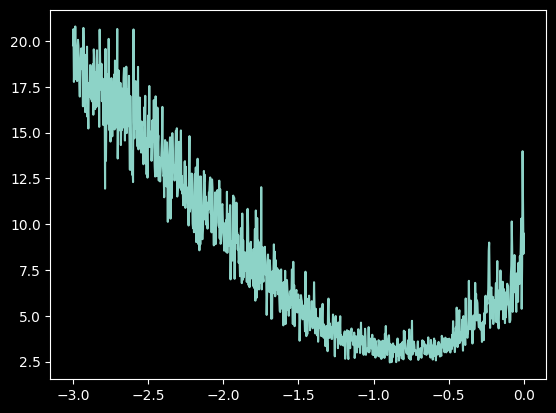

In [69]:
plt.plot(lri, lossi)

# Increase # of Neurons and Utilize Dataset Split

In [ ]:
# Architecture: same as v1 but hidden width 100 -> 500. embed stays at 2.
# Dataset gets split into train/dev/test in the cells below.
print(f'{X.shape=}, {Y.shape=}')

generator = torch.Generator().manual_seed(2147483647)
lookup = torch.randn((27, 2), generator=generator)

weights1 = torch.randn((6, 500), generator=generator)
biases1 = torch.randn(500, generator=generator)
weights2 = torch.randn((500, 27), generator=generator)
biases2 = torch.randn(27, generator=generator)

parameters = [lookup, weights1, biases1, weights2, biases2]
print(f'Total Parameters: {sum(parameter.nelement() for parameter in parameters)}')

for parameter in parameters:
    parameter.requires_grad = True

In [121]:
# Function to build a dataset given a list of words

def build_dataset(words):
    block_size = 3 # Context Size
    X, Y = [], []
    
    for word in words:
        context = [0] * block_size

        for c in word + '.':
            ix = stoi[c]
            X.append(context)
            Y.append(ix)

            context = context[1:] + [ix] # Crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(f'{X.shape=}, {Y.shape=}')
    return X, Y


In [122]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

X.shape=torch.Size([182625, 3]), Y.shape=torch.Size([182625])
X.shape=torch.Size([22655, 3]), Y.shape=torch.Size([22655])
X.shape=torch.Size([22866, 3]), Y.shape=torch.Size([22866])


In [124]:
lri = []
lossi = []
steps = 50000

for i in range(steps):
    # Construct Mini batches
    ix = torch.randint(0, Xtr.shape[0], (32, ))

    # Forward Pass
    embedding = lookup[Xtr[ix]] # 32, 3, 2
    hidden = torch.tanh(embedding.view(-1, 6) @ weights1 + biases1)
    logits = hidden @ weights2 + biases2

    loss = F.cross_entropy(logits, Ytr[ix])

    # Backward Pass
    for parameter in parameters:
        parameter.grad = None

    loss.backward()

    # Update
    learning_rate = 0.01
    for parameter in parameters:
        parameter.data += -learning_rate * parameter.grad

print(f'Loss: {loss}')

Loss: 2.0551857948303223


In [125]:
# Evaluate the Loss on Dev set
embedding = lookup[Xdev]
h = torch.tanh(embedding.view(-1, 6) @ weights1 + biases1)
logits = h @ weights2 + biases2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2712, grad_fn=<NllLossBackward0>)

In [126]:
# Evaluate the Loss on Training Set
embedding = lookup[Xtr]
h = torch.tanh(embedding.view(-1, 6) @ weights1 + biases1)
logits = h @ weights2 + biases2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2643, grad_fn=<NllLossBackward0>)

In [ ]:
# Visualize the learned 2D character embeddings.
# Characters that play similar roles in names should cluster (e.g. vowels near each other).
plt.figure(figsize=(8, 8))
plt.scatter(lookup[:,0].data, lookup[:,1].data, s=200)
for i in range(lookup.shape[0]):
    plt.text(lookup[i, 0].item(), lookup[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

# Increase Character Embeddings

In [ ]:
# Architecture: bump n_embed 2 -> 10. With richer embeddings:
# hidden_input = block_size * n_embed = 3 * 10 = 30. Hidden width = 300.
print(f'{X.shape=}, {Y.shape=}')

generator = torch.Generator().manual_seed(2147483647)
lookup = torch.randn((27, 10), generator=generator)

weights1 = torch.randn((30, 300), generator=generator)
biases1 = torch.randn(300, generator=generator)
weights2 = torch.randn((300, 27), generator=generator)
biases2 = torch.randn(27, generator=generator)

parameters = [lookup, weights1, biases1, weights2, biases2]
print(f'Total Parameters: {sum(parameter.nelement() for parameter in parameters)}')

for parameter in parameters:
    parameter.requires_grad = True

In [130]:
lri = []
lossi = []
stepi = []
steps = 50000

In [143]:
for i in range(steps):
    # Construct Mini batches
    ix = torch.randint(0, Xtr.shape[0], (32, ))

    # Forward Pass
    embedding = lookup[Xtr[ix]] # 32, 3, 2
    hidden = torch.tanh(embedding.view(-1, 30) @ weights1 + biases1)
    logits = hidden @ weights2 + biases2

    loss = F.cross_entropy(logits, Ytr[ix])

    # Backward Pass
    for parameter in parameters:
        parameter.grad = None

    loss.backward()

    # Update
    learning_rate = 0.01
    for parameter in parameters:
        parameter.data += -learning_rate * parameter.grad
    
    # Track Stats
    stepi.append(i)
    lossi.append(loss.log10().item())

print(f'Loss: {loss}')

Loss: 2.0637147426605225


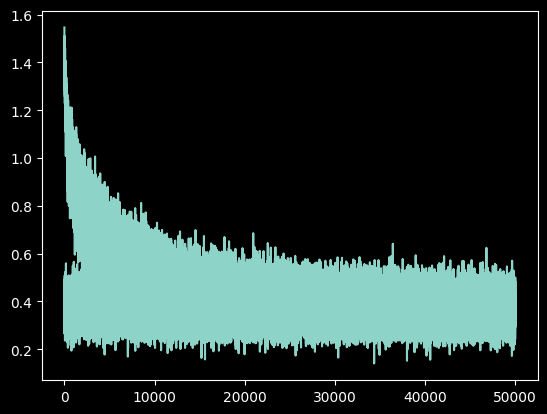

In [144]:
plt.plot(stepi, lossi)

In [145]:
# Evaluate the Loss on Dev set
embedding = lookup[Xdev]
h = torch.tanh(embedding.view(-1, 30) @ weights1 + biases1)
logits = h @ weights2 + biases2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3005, grad_fn=<NllLossBackward0>)

In [146]:
# Evaluate the Loss on Training Set
embedding = lookup[Xtr]
h = torch.tanh(embedding.view(-1, 30) @ weights1 + biases1)
logits = h @ weights2 + biases2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2784, grad_fn=<NllLossBackward0>)

In [147]:
# Sample from the model
generator = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        embedding = lookup[torch.tensor(context)]
        h = torch.tanh(embedding.view(1, -1) @ weights1 + biases1)
        logits = h @ weights2 + biases2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=generator).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))



carpahza.
jahleigh.
mili.
thaylenah.
sae.
mahuen.
ameryna.
kaqui.
nelenia.
chaiiv.
kalegy.
hhymondin.
quint.
shlin.
alvin.
quinathoudiarisi.
jaquini.
sabee.
dedi.
abetley.


# The Best Setup?

In [148]:
# Hyperparameters:
block_size = 4        # context length (chars used to predict next)
n_embed = 10          # embedding dimensions per char
n_hidden = 300        # hidden layer width
batch_size = 32       # examples per gradient step
total_steps = 100000  # total training steps
lr_hot = 0.1          # learning rate for the 'hot' phase
lr_cold = 0.01        # learning rate for the 'cold' phase
hot_fraction = 0.5    # fraction of steps at lr_hot before dropping to lr_cold
seed = 2147483647

vocab_size = 27       # fixed by the dataset (26 letters + '.' boundary)

print(f"Setup: block_size={block_size}, n_embed={n_embed}, n_hidden={n_hidden}, "
      f"batch_size={batch_size}, total_steps={total_steps}, lr={lr_hot} -> {lr_cold}")

Setup: block_size=4, n_embed=10, n_hidden=300, batch_size=32, total_steps=100000, lr=0.1 -> 0.01


In [149]:
# Rebuild train/dev/test using the current block_size.
# Redefines build_dataset to take block_size as a parameter (overriding the earlier hardcoded version).
def build_dataset(words, block_size):
    X, Y = [], []
    for word in words:
        context = [0] * block_size
        for c in word + '.':
            ix = stoi[c]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1], block_size)
Xdev, Ydev = build_dataset(words[n1:n2], block_size)
Xte, Yte = build_dataset(words[n2:], block_size)
print(f'{Xtr.shape=}, {Xdev.shape=}, {Xte.shape=}')

Xtr.shape=torch.Size([182580, 4]), Xdev.shape=torch.Size([22767, 4]), Xte.shape=torch.Size([22799, 4])


In [150]:
# Initialize all parameters from a fresh seed.
generator = torch.Generator().manual_seed(seed)

lookup   = torch.randn((vocab_size, n_embed),               generator=generator)
weights1 = torch.randn((block_size * n_embed, n_hidden),    generator=generator)
biases1  = torch.randn(n_hidden,                            generator=generator)
weights2 = torch.randn((n_hidden, vocab_size),              generator=generator)
biases2  = torch.randn(vocab_size,                          generator=generator)

parameters = [lookup, weights1, biases1, weights2, biases2]
print(f'Total parameters: {sum(p.nelement() for p in parameters)}')

for p in parameters:
    p.requires_grad = True

Total parameters: 20697


Final batch loss: 2.2004


Text(0, 0.5, 'log10(loss)')

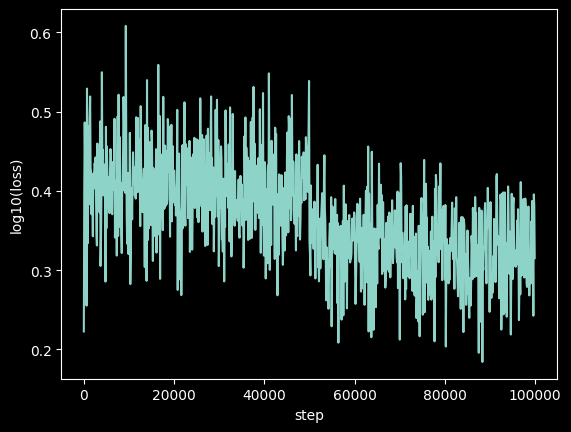

In [154]:
# Train with a stepped LR schedule: lr_hot for the first hot_fraction of steps, then lr_cold.
hot_steps = int(total_steps * hot_fraction)
lossi = []
stepi = []

for i in range(total_steps):
    # Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))

    # Forward pass
    embedding = lookup[Xtr[ix]]
    hidden = torch.tanh(embedding.view(-1, block_size * n_embed) @ weights1 + biases1)
    logits = hidden @ weights2 + biases2
    loss = F.cross_entropy(logits, Ytr[ix])

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update with stepped LR
    lr = lr_hot if i < hot_steps else lr_cold
    for p in parameters:
        p.data += -lr * p.grad

    # Track loss every 100 steps to keep the lossi list small
    if i % 100 == 0:
        stepi.append(i)
        lossi.append(loss.log10().item())

print(f'Final batch loss: {loss.item():.4f}')
plt.plot(stepi, lossi)
plt.xlabel('step')
plt.ylabel('log10(loss)')

In [155]:
# Full-dataset evaluation on train and dev (no_grad keeps it from tracking gradients).
@torch.no_grad()
def evaluate(X, Y):
    embedding = lookup[X]
    hidden = torch.tanh(embedding.view(-1, block_size * n_embed) @ weights1 + biases1)
    logits = hidden @ weights2 + biases2
    return F.cross_entropy(logits, Y).item()

print(f'Train loss: {evaluate(Xtr, Ytr):.4f}')
print(f'Dev loss:   {evaluate(Xdev, Ydev):.4f}')

Train loss: 2.1314
Dev loss:   2.1721


In [156]:
# Sample 20 names from the trained model.
sample_gen = torch.Generator().manual_seed(seed + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        embedding = lookup[torch.tensor(context)]
        hidden = torch.tanh(embedding.view(1, -1) @ weights1 + biases1)
        logits = hidden @ weights2 + biases2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=sample_gen).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carman.
amillian.
kimri.
rehty.
salani.
ejarontefam.
sart.
kaquil.
ramara.
chaii.
desley.
phali.
join.
quint.
sulin.
alivian.
watero.
dearyx.
kakae.
pirra.
